In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("/content/processed_feedback.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7000, 4)


,feedback,processed_text,sentiment,category
0,"Honestly, i would like to schedule deliveries ...",honestly would like schedule delivery need ass...,neutral,feature_request
1,"For some reason, the website response time is ...",reason website response time poor fix,negative,performance
2,I am having trouble because the application is...,trouble application lagging badly please look,negative,performance
3,"Honestly, the payment page shows an error I ne...",honestly payment page show error need assistance,negative,payment
4,I noticed that the application interface is ea...,noticed application interface easy use please ...,negative,ui


<Axes: title={'center': 'Sentiment Distribution'}, xlabel='sentiment'>

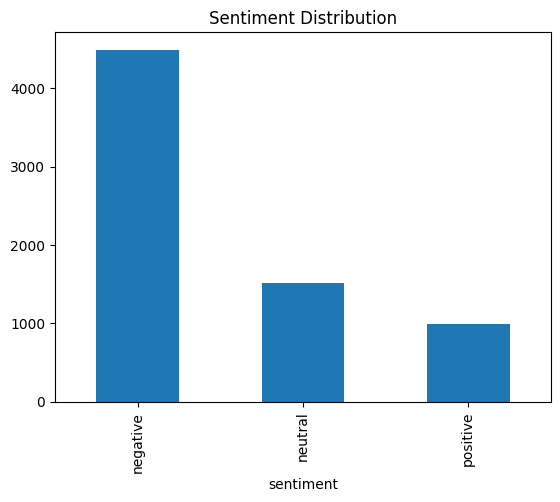

In [4]:
df["sentiment"].value_counts().plot(
    kind="bar",
    title="Sentiment Distribution"
)

In [5]:
X = df["processed_text"]
y = df["sentiment"]

In [6]:
import sklearn
print(sklearn.__version__)

1.6.1


In [7]:
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 5600
Testing samples: 1400


In [10]:
  from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (5600, 168)
Testing TF-IDF shape: (1400, 168)


In [21]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_tfidf, y_train)

print("Model trained successfully!")

Model trained successfully!


In [22]:
y_pred = model.predict(X_test_tfidf)

print(y_pred[:20])

['negative' 'neutral' 'neutral' 'positive' 'negative' 'positive'
 'negative' 'positive' 'negative' 'negative' 'neutral' 'negative'
 'negative' 'negative' 'negative' 'positive' 'positive' 'negative'
 'positive' 'negative']


In [23]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(20)

,Actual,Predicted
0,negative,negative
1,neutral,neutral
2,neutral,neutral
3,negative,positive
4,negative,negative
5,neutral,positive
6,neutral,negative
7,positive,positive
8,negative,negative
9,neutral,negative


In [24]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7592857142857142


In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.91      0.81      0.86       898
     neutral       0.82      0.58      0.68       304
    positive       0.42      0.80      0.55       198

    accuracy                           0.76      1400
   macro avg       0.71      0.73      0.69      1400
weighted avg       0.82      0.76      0.77      1400



In [26]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["negative", "neutral", "positive"]
)

print(cm)

[[728   0 170]
 [ 74 176  54]
 [  0  39 159]]


In [28]:
new_feedback = [
    "Payment keeps failing and this is extremely frustrating",
    ]

new_feedback_tfidf = vectorizer.transform(new_feedback)

predictions = model.predict(new_feedback_tfidf)

for text, prediction in zip(new_feedback, predictions):
    print("Feedback:", text)
    print("Predicted sentiment:", prediction)
    print()

Feedback: Payment keeps failing and this is extremely frustrating
Predicted sentiment: negative

